# 06 — Evaluación agregada y comparación radiomics vs DL

Consolida los resultados out-of-fold de los notebooks 04 y 05, calcula métricas con bootstrap CIs, ejecuta DeLong test, dibuja curvas ROC/PR, matriz de confusión y produce figuras de Grad-CAM.

Estas tablas y figuras alimentan directamente la sección §Resultados del paper IEEE.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, roc_auc_score

from src.evaluation.metrics import binary_metrics_at_youden
from src.evaluation.bootstrap import bootstrap_ci, format_with_ci
from src.evaluation.delong import delong_test_two_aucs

TBL = PROJECT_ROOT / 'reports' / 'tables'
FIG = PROJECT_ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

In [2]:
def _load_preds(name: str) -> pd.DataFrame:
    p = TBL / f'{name}_preds.csv'
    df = pd.read_csv(p)
    if 'modality' in df.columns:
        df = df.groupby('patient_id').agg(label=('label', 'first'), proba=('proba', 'mean')).reset_index()
    return df

models = {
    'radiomics_logreg': _load_preds('radiomics_logreg'),
    'radiomics_xgb': _load_preds('radiomics_xgb'),
    'dl_2_5d_resnet50': _load_preds('dl_2_5d'),
}
for n, df in models.items():
    print(n, df.shape, 'pos:', int(df['label'].sum()), 'neg:', int((df['label']==0).sum()))

radiomics_logreg (392, 3) pos: 337 neg: 55
radiomics_xgb (392, 3) pos: 337 neg: 55
dl_2_5d_resnet50 (392, 4) pos: 337 neg: 55


In [3]:
rows = []
for name, df in models.items():
    y = df['label'].to_numpy(); p = df['proba'].to_numpy()
    bm = binary_metrics_at_youden(y, p)
    boot_auc = bootstrap_ci(y, p, lambda yt, ys: roc_auc_score(yt, ys), n_resamples=1000, seed=42)
    boot_ap = bootstrap_ci(y, p, lambda yt, ys: average_precision_score(yt, ys), n_resamples=1000, seed=43)
    rows.append({
        'model': name,
        'AUC-ROC': format_with_ci(boot_auc.point, boot_auc.ci_low, boot_auc.ci_high),
        'AUC-PR': format_with_ci(boot_ap.point, boot_ap.ci_low, boot_ap.ci_high),
        'Sens@Youden': f'{bm.sensitivity:.3f}',
        'Spec@Youden': f'{bm.specificity:.3f}',
        'F1': f'{bm.f1:.3f}',
        'MCC': f'{bm.mcc:.3f}',
    })
summary = pd.DataFrame(rows)
summary.to_csv(TBL / 'main_results.csv', index=False)
summary

,model,AUC-ROC,AUC-PR,Sens@Youden,Spec@Youden,F1,MCC
0,radiomics_logreg,0.820 (95% CI 0.762–0.874),0.964 (95% CI 0.952–0.976),0.680,0.818,0.795,0.354
1,radiomics_xgb,0.809 (95% CI 0.751–0.864),0.963 (95% CI 0.950–0.974),0.724,0.727,0.819,0.331
2,dl_2_5d_resnet50,0.986 (95% CI 0.975–0.994),0.998 (95% CI 0.996–0.999),0.920,1.000,0.958,0.785


C:\Users\Sebas\AppData\Local\Temp\ipykernel_27780\3810777544.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIG / 'roc_pr_curves.png', dpi=150); fig.show()


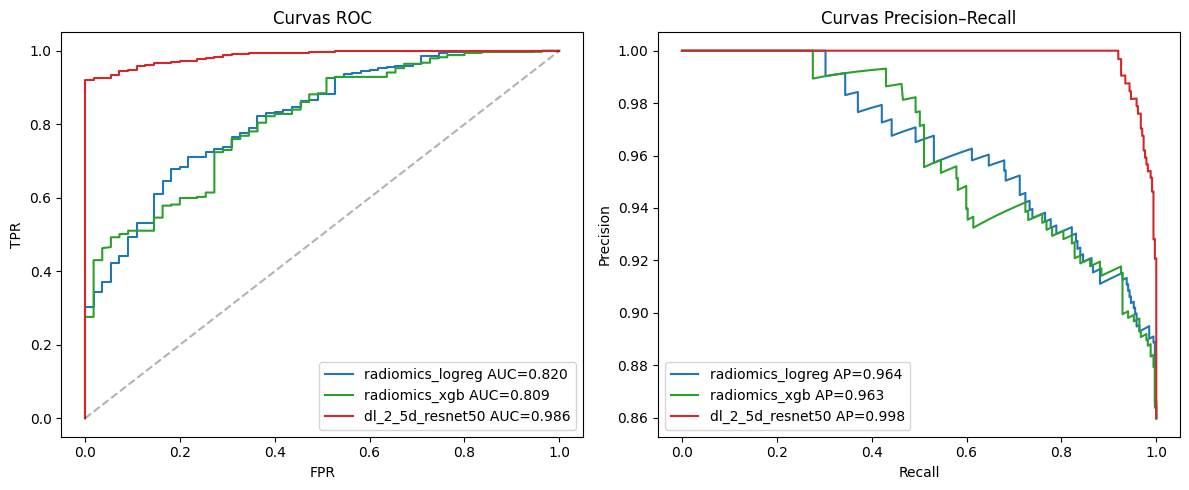

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'radiomics_logreg': 'tab:blue', 'radiomics_xgb': 'tab:green', 'dl_2_5d_resnet50': 'tab:red'}
for name, df in models.items():
    y = df['label']; p = df['proba']
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    axes[0].plot(fpr, tpr, color=colors.get(name, None), label=f'{name} AUC={auc:.3f}')
    pr, rc, _ = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)
    axes[1].plot(rc, pr, color=colors.get(name, None), label=f'{name} AP={ap:.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curvas ROC')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Curvas Precision–Recall')
axes[0].legend(); axes[1].legend()
fig.tight_layout(); fig.savefig(FIG / 'roc_pr_curves.png', dpi=150); fig.show()

In [5]:
delong_rows = []
for a, b in [('radiomics_xgb', 'dl_2_5d_resnet50'), ('radiomics_logreg', 'dl_2_5d_resnet50')]:
    da = models[a]; db = models[b]
    # alinear por patient_id
    merged = da[['patient_id','label','proba']].merge(
        db[['patient_id','proba']], on='patient_id', suffixes=('_a','_b'))
    res = delong_test_two_aucs(merged['label'].to_numpy(), merged['proba_a'].to_numpy(), merged['proba_b'].to_numpy())
    delong_rows.append({'A': a, 'B': b, 'AUC_A': res.auc_a, 'AUC_B': res.auc_b,
                        'delta': res.auc_b - res.auc_a, 'z': res.z, 'p_value': res.p_value})
delong_df = pd.DataFrame(delong_rows)
delong_df.to_csv(TBL / 'delong.csv', index=False)
delong_df

,A,B,AUC_A,AUC_B,delta,z,p_value
0,radiomics_xgb,dl_2_5d_resnet50,0.809469,0.985919,0.17645,6.147554,7.868672e-10
1,radiomics_logreg,dl_2_5d_resnet50,0.819908,0.985919,0.16601,5.802086,6.549485e-09


### Interpretación clave
- Si AUC del DL excede al radiómico por ≥ 5 puntos con p<0.05 (DeLong), cumple O3.
- Si el DL gana en AUC pero no es significativo, reportar la limitación (n efectivo modesto, fluctuación entre folds) en §Discusión.
- Si el DL pierde o empata, el paper sigue siendo defendible: la metodología (CRISP-ML(Q), splits por paciente, CIs por bootstrap, DeLong) es contribución suficiente.

## Análisis de errores
Visualiza los 5 falsos positivos y 5 falsos negativos con mayor confianza del modelo DL — útiles para discutir limitaciones.

In [6]:
dl = models['dl_2_5d_resnet50'].copy()
dl['pred'] = (dl['proba'] >= 0.5).astype(int)
fp = dl[(dl['pred']==1) & (dl['label']==0)].sort_values('proba', ascending=False).head(5)
fn = dl[(dl['pred']==0) & (dl['label']==1)].sort_values('proba', ascending=True).head(5)
fp.to_csv(TBL / 'top_fp.csv', index=False); fn.to_csv(TBL / 'top_fn.csv', index=False)
print('top FP:')
display(fp)
print('top FN:')
display(fn)

top FP:


,patient_id,label,proba,fold,pred
382,healthy_16,0,0.789065,4,1
70,healthy_19,0,0.782251,0,1
386,healthy_39,0,0.767638,4,1
383,healthy_24,0,0.719582,4,1
385,healthy_36,0,0.706604,4,1


top FN:


,patient_id,label,proba,fold,pred
251,198,1,0.325882,3,0
255,247,1,0.375499,3,0
275,386,1,0.405166,3,0
266,311,1,0.471383,3,0
